In [1]:
import pandas as pd
import numpy as np

rfm = pd.read_csv('../data/rfm.csv', sep=';')
print(rfm.shape)
rfm.head()

(5939, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,17,-64.68
1,12347,3,8,5633.32
2,12348,76,5,2019.40
3,12349,19,5,4404.54
4,12350,311,1,334.40


In [2]:
print("Before:", rfm.shape)
rfm = rfm[rfm['Monetary'] > 0]
print("After:", rfm.shape)

Before: (5939, 4)
After: (5837, 4)


## Data Preparation
Dropped 102 customers with net negative Monetary value (returns exceeded 
purchases), leaving 5,837 customers for clustering.

In [3]:
rfm_log = rfm.copy()
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

rfm_log[['Recency','Frequency','Monetary']].describe()

,Recency,Frequency,Monetary
count,5837.000000,5837.000000,5837.000000
mean,197.901833,1.669215,6.813129
std,207.864821,0.867239,1.375672
min,1.000000,0.693147,1.064711
25%,25.000000,1.098612,5.835688
50%,93.000000,1.609438,6.778648
75%,376.000000,2.197225,7.713392
max,739.000000,6.236370,13.301708


In [4]:
from sklearn.preprocessing import StandardScaler

features = ['Recency', 'Frequency', 'Monetary']
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[features])

print(rfm_scaled.shape)
print("Mean:", rfm_scaled.mean(axis=0).round(3))
print("Std:", rfm_scaled.std(axis=0).round(3))

(5837, 3)
Mean: [-0.  0.  0.]
Std: [1. 1. 1.]


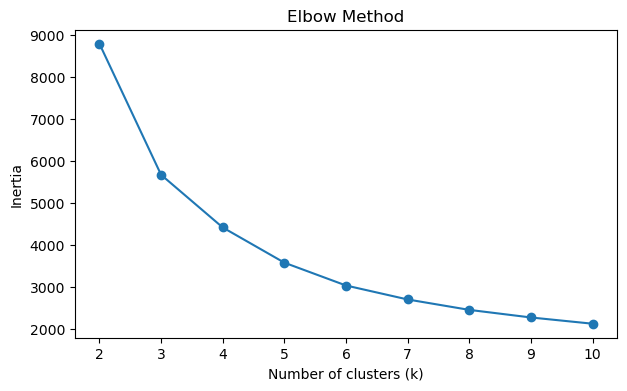

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [6]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"k={k}: silhouette = {score:.3f}")

k=2: silhouette = 0.418
k=3: silhouette = 0.400
k=4: silhouette = 0.363
k=5: silhouette = 0.368
k=6: silhouette = 0.346
k=7: silhouette = 0.335
k=8: silhouette = 0.313
k=9: silhouette = 0.308
k=10: silhouette = 0.293


## Choosing k
Silhouette scores peaked at k=2 (0.418) and declined steadily, but two clusters 
are not actionable for marketing. The elbow plot flattens around k=4, and its 
silhouette (0.363) remains close to k=3 (0.400). k=4 was selected as the best 
balance of statistical separation and business interpretability. The modest 
scores across all k suggest customer behaviour is closer to a continuum than 
a set of naturally distinct groups — these segments are useful constructs 
rather than sharp natural divisions.

In [7]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm['Cluster'].value_counts().sort_index()

Cluster
0     949
1    1407
2    1877
3    1604
Name: count, dtype: int64

In [8]:
profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).round(2)

profile.columns = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Count']
profile

,Avg_Recency,Avg_Frequency,Avg_Monetary,Count
Cluster,,,,
0,40.33,27.63,12454.82,949
1,103.20,1.98,425.85,1407
2,98.18,6.63,1876.50,1877
3,490.90,2.00,499.66,1604


In [9]:
segment_map = {
    0: 'Champions',
    1: 'New / Low-Engagement',
    2: 'Loyal Customers',
    3: 'Lost'
}
rfm['Segment'] = rfm['Cluster'].map(segment_map)

# Revenue contribution per segment
rev = rfm.groupby('Segment')['Monetary'].agg(['sum', 'mean', 'count'])
rev['pct_of_revenue'] = (rev['sum'] / rev['sum'].sum() * 100).round(1)
rev['pct_of_customers'] = (rev['count'] / rev['count'].sum() * 100).round(1)
rev.round(2)

,sum,mean,count,pct_of_revenue,pct_of_customers
Segment,,,,,
Champions,11819628.11,12454.82,949,70.6,16.3
Lost,801450.75,499.66,1604,4.8,27.5
Loyal Customers,3522187.31,1876.50,1877,21.0,32.2
New / Low-Engagement,599164.43,425.85,1407,3.6,24.1


## Segment Profiles and Revenue Concentration

| Segment | Customers | % of Base | % of Revenue | Avg Spend |
|---|---|---|---|---|
| Champions | 949 | 16.3% | 70.6% | £12,455 |
| Loyal Customers | 1,877 | 32.2% | 21.0% | £1,877 |
| Lost | 1,604 | 27.5% | 4.8% | £500 |
| New / Low-Engagement | 1,407 | 24.1% | 3.6% | £426 |

16.3% of customers generate 70.6% of revenue — retention investment should 
concentrate on the 949 Champions, where a single lost customer is worth roughly 
25 low-engagement customers. The 1,604 Lost customers (16+ months inactive, 
4.8% of revenue) are unlikely to justify win-back spend.

Clusters 1 and 3 have near-identical Frequency and Monetary profiles and are 
separated almost entirely by Recency (103 vs 491 days) — same value, different 
reachability, requiring different treatment.

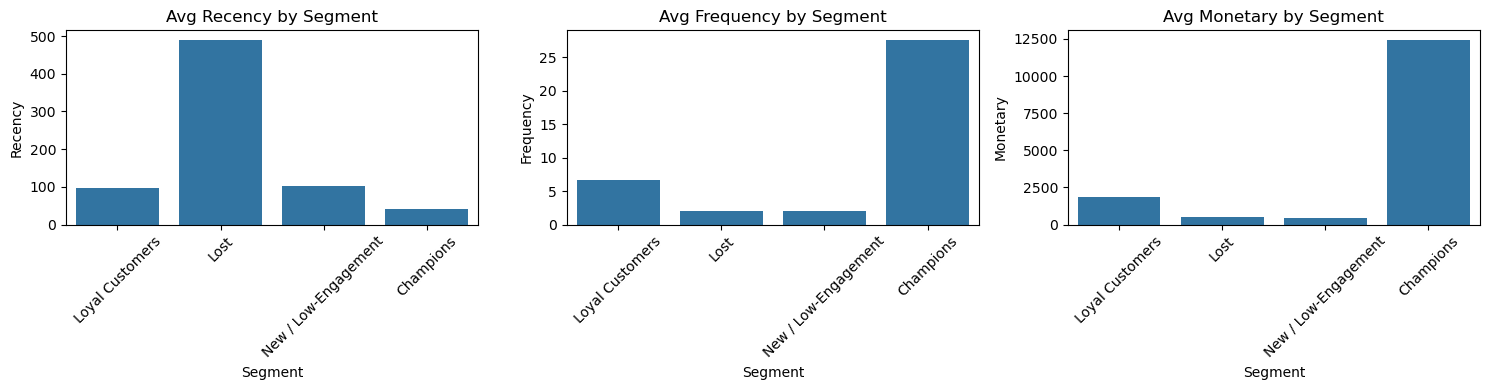

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.barplot(data=rfm, x='Segment', y='Recency', ax=axes[0], errorbar=None)
axes[0].set_title('Avg Recency by Segment')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=rfm, x='Segment', y='Frequency', ax=axes[1], errorbar=None)
axes[1].set_title('Avg Frequency by Segment')
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(data=rfm, x='Segment', y='Monetary', ax=axes[2], errorbar=None)
axes[2].set_title('Avg Monetary by Segment')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Champions dominate both Frequency (27.6 orders) and Monetary (£12,455) while 
having the lowest Recency. Lost customers are separated almost entirely by 
Recency — their Frequency and Monetary are comparable to New/Low-Engagement.

In [11]:
rfm.to_csv('../data/rfm_segments.csv', index=False)
print("Saved:", rfm.shape)
rfm.head()

Saved: (5837, 6)


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
1,12347,3,8,5633.32,2,Loyal Customers
2,12348,76,5,2019.40,2,Loyal Customers
3,12349,19,5,4404.54,2,Loyal Customers
4,12350,311,1,334.40,3,Lost
5,12351,376,1,300.93,3,Lost


## Cluster Stability
K-Means initialises randomly, so results can vary between runs. Testing whether 
the segments are reproducible or an artifact of one particular initialisation.

In [12]:
from sklearn.metrics import adjusted_rand_score

base = KMeans(n_clusters=4, random_state=0, n_init=10).fit_predict(rfm_scaled)

scores = []
for seed in range(1, 11):
    labels = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(rfm_scaled)
    scores.append(adjusted_rand_score(base, labels))

print(f"Mean ARI: {np.mean(scores):.3f}")
print(f"Min: {min(scores):.3f}")
print(f"Max: {max(scores):.3f}")

Mean ARI: 0.989
Min: 0.986
Max: 1.000


Mean ARI across 10 random initialisations: 0.989 (min 0.986, max 1.000). 
The segments are highly reproducible — roughly 99% of customers land in the 
same group regardless of initialisation. Combined with the modest silhouette 
score (0.363), this suggests the boundaries between segments are soft but the 
segment structure itself is stable and not an artifact of chance.

## Baseline Comparison: Quartile Scoring
Traditional RFM scoring ranks customers into quartiles on each dimension without 
any machine learning. Testing whether K-Means adds value over this simpler approach.

In [13]:
rfm.columns

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment'], dtype='object')

In [14]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,40.33,27.63,12454.82
1,103.20,1.98,425.85
2,98.18,6.63,1876.50
3,490.90,2.00,499.66


In [15]:
segment_map = {
    0: 'Champions',
    1: 'New / Low-Engagement',
    2: 'Loyal Customers',
    3: 'Lost'
}
rfm['Segment'] = rfm['Cluster'].map(segment_map)

print(rfm.columns.tolist())

['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']


In [16]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4]).astype(int)
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

pd.crosstab(rfm['Segment'], rfm['RFM_score'])

RFM_score,3,4,5,6,7,8,9,10,11,12
Segment,,,,,,,,,,
Champions,0,0,0,0,0,1,10,94,269,575
Lost,563,384,298,213,123,21,2,0,0,0
Loyal Customers,0,0,0,3,171,402,511,466,250,74
New / Low-Engagement,0,186,296,406,292,192,35,0,0,0


Quartile scoring and K-Means agree at the extremes — 938 of 949 Champions score 
10-12, and 1,581 of 1,604 Lost customers score 3-7. They diverge in the middle: 
RFM score 8 alone contains 616 customers spread across all four K-Means segments.

The reason is that quartile scoring sums R, F, and M into a single number, 
discarding which dimension drove the score. A customer with R=1, F=3, M=4 (lapsed 
but formerly valuable) and one with R=4, F=2, M=2 (recent but low-value) both 
score 8, despite requiring opposite interventions. K-Means preserves the three 
dimensions separately and separates them correctly.

K-Means adds most value in the mid-range, where the majority of customers sit 
and where targeting decisions are least obvious.

## Retention Budget Implications

In [17]:
champions = rfm[rfm['Segment'] == 'Champions']
n_champions = len(champions)
avg_champion_value = champions['Monetary'].mean()

campaign_cost_per_customer = 50
total_campaign_cost = n_champions * campaign_cost_per_customer
breakeven_customers = total_campaign_cost / avg_champion_value

print(f"Champions: {n_champions}")
print(f"Average Champion value: £{avg_champion_value:,.0f}")
print(f"Campaign cost at £{campaign_cost_per_customer}/customer: £{total_campaign_cost:,.0f}")
print(f"Break-even: preventing {breakeven_customers:.1f} defections covers the cost")

Champions: 949
Average Champion value: £12,455
Campaign cost at £50/customer: £47,450
Break-even: preventing 3.8 defections covers the cost


Reaching all 949 Champions at an assumed £50 per customer costs £47,450. 
Preventing just 3.8 defections covers that cost — a 0.4% success rate makes 
the campaign break even. Given each Champion is worth £12,455 on average, 
retention spend on this segment carries very low risk. The £50 figure is an 
assumption; the point is the ratio, not the precise number.